# Sales Potential Segmentation of Seasonal Customers Using Clustering

This project analyzes the sales potential of seasonal customers such as retail stores, bars, and restaurants.

The objective of the analysis is to identify groups of customers with similar characteristics based on traffic levels, refrigeration capacity,
location characteristics, and historical sales performance.

Using clustering techniques, customers are segmented into four business categories:

Gold  
Silver  
Bronze  
Iron  

These segments represent different levels of sales potential and help businesses prioritize investments, equipment allocation, and sales strategies.

## Research Question

How can clustering algorithms be used to segment seasonal customers such as stores, bars, and restaurants based on traffic levels,
refrigeration capacity, and historical sales in order to identify customers with the highest sales potential?

## Project Objectives

The main objectives of this project are:

- To explore the dataset and understand customer characteristics
- To analyze the relationship between traffic, refrigeration capacity, and sales
- To preprocess the dataset for clustering analysis
- To apply clustering algorithms to group customers with similar characteristics
- To classify customers into four sales potential segments: Gold, Silver, Bronze, and Iron
- To interpret the results from a business perspective

## Dataset Description

The dataset contains information about seasonal customers such as retail stores, bars, and restaurants.

Each row represents a customer outlet and includes attributes describing the environment, equipment availability, and sales performance.

The dataset contains the following variables:

Customer – Unique identifier of the outlet

City – Name of the city where the outlet operates

Channel – Type of customer channel (Hotels, QSR, etc.)

Segment – Existing traffic-based classification

Urbanicity – Level of urbanization of the area

Traffic – Estimated number of people passing near the outlet

Traffic Index – Category of traffic intensity

Equipment (Y/N) – Indicates whether a refrigerator is installed at the outlet

'# of doors – Number of refrigerator doors installed at the outlet

Sales 2025 CS – Sales volume generated by the customer

Refrigeration capacity, measured by the number of refrigerator doors, is an important operational factor that influences the ability of 
a customer to sell cold beverages during the summer season.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import dendrogram, linkage

### Load Dataset

In [2]:
df = pd.read_csv("Segmentation_Summer Seasonal.dat", sep="\t", encoding="cp1251")

df.head()

,Customer,City,Channel,Segment,Urbanicity,Traffic,Traffic Index,Equipment (Y/N),# of doors,Sales 2025 CS
0,10000,ЗЛАТНИ ПЯСЪЦИ,Hotels,Seasonal High Traffic,3,"30422,86",High,Yes,6,0
1,10001,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal High Traffic,1,"58764,25",High,Yes,0,0
2,10002,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal High Traffic,1,"32763,5",High,Yes,0,0
3,10003,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal Low/Mid Traffic,1,"23147,5",Medium,Yes,0,0
4,10004,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal High Traffic,1,"34339,25",High,Yes,2,56


## Data Cleaning

Some numeric values contain commas as decimal separators. These values need to be converted into numeric format for analysis.

The Equipment column is also converted into numeric values.

### Data Cleaning Code

In [3]:
# Fix decimal separator in Traffic
df["Traffic"] = df["Traffic"].astype(str).str.replace(",", ".").astype(float)

# Convert equipment column to numeric
df["Equipment (Y/N)"] = df["Equipment (Y/N)"].map({
    "Yes":1,
    "No":0
})

# Convert "# of doors" to float
df["# of doors"] = df["# of doors"].astype(str).str.replace(",", ".").astype(float)

# Convert "Sales 2025 CS" to float
df["Sales 2025 CS"] = df["Sales 2025 CS"].astype(str).str.replace(",", ".").astype(float)

## Exploratory Data Analysis

Before applying clustering algorithms, we explore the dataset to understand the distribution of key variables such as traffic,
refrigeration capacity, and sales.

### Dataset Structure

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer         5574 non-null   int64  
 1   City             5574 non-null   object 
 2   Channel          5574 non-null   object 
 3   Segment          5574 non-null   object 
 4   Urbanicity       5574 non-null   int64  
 5   Traffic          5574 non-null   float64
 6   Traffic Index    5574 non-null   object 
 7   Equipment (Y/N)  5574 non-null   int64  
 8   # of doors       5574 non-null   float64
 9   Sales 2025 CS    5574 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 435.6+ KB


,Customer,Urbanicity,Traffic,Equipment (Y/N),# of doors,Sales 2025 CS
count,5574.000000,5574.000000,5574.000000,5574.000000,5574.000000,5574.000000
mean,12786.500000,4.058306,20450.364615,0.698780,1.748924,194.558431
std,1609.219531,2.060891,15406.316568,0.458829,2.216891,592.370489
min,10000.000000,1.000000,10.540000,0.000000,0.000000,0.000000
25%,11393.250000,3.000000,10069.115000,0.000000,0.000000,0.000000
50%,12786.500000,4.000000,17299.400000,1.000000,1.000000,23.000000
75%,14179.750000,5.000000,28627.760000,1.000000,2.500000,189.750000
max,15573.000000,10.000000,151311.830000,1.000000,28.000000,16300.000000


### Traffic Distribution

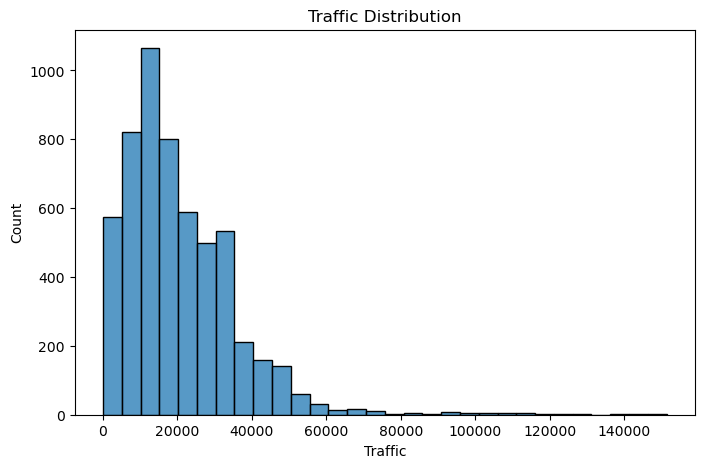

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(df["Traffic"], bins=30)

plt.title("Traffic Distribution")

plt.show()

### Refrigerator Capacity vs Sales

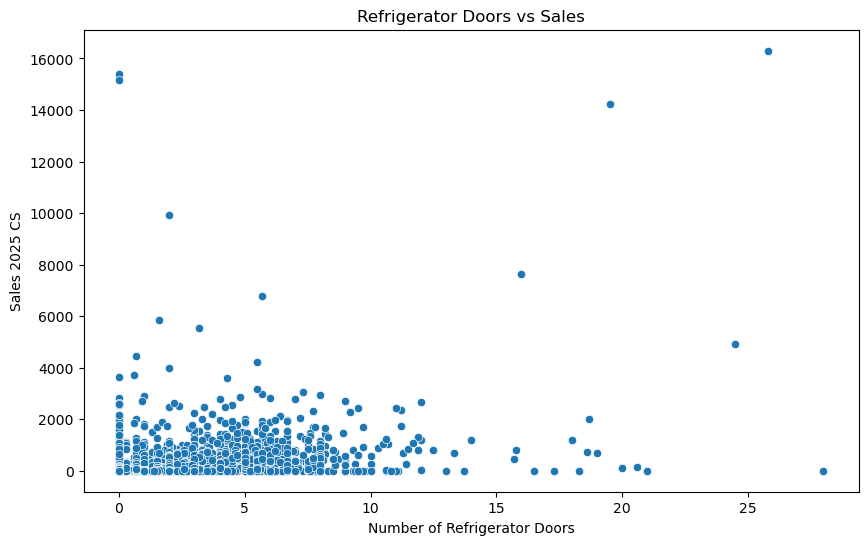

In [6]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["# of doors"],
    y=df["Sales 2025 CS"]
)

plt.title("Refrigerator Doors vs Sales")

plt.xlabel("Number of Refrigerator Doors")
plt.ylabel("Sales 2025 CS")

plt.show()

### Traffic vs Sales

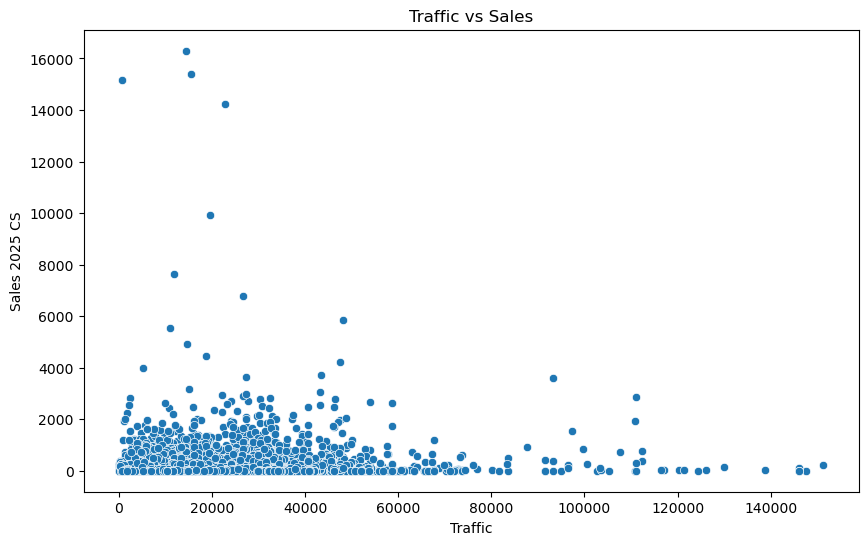

In [7]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Traffic"],
    y=df["Sales 2025 CS"]
)

plt.title("Traffic vs Sales")

plt.show()

### Equipment Impact

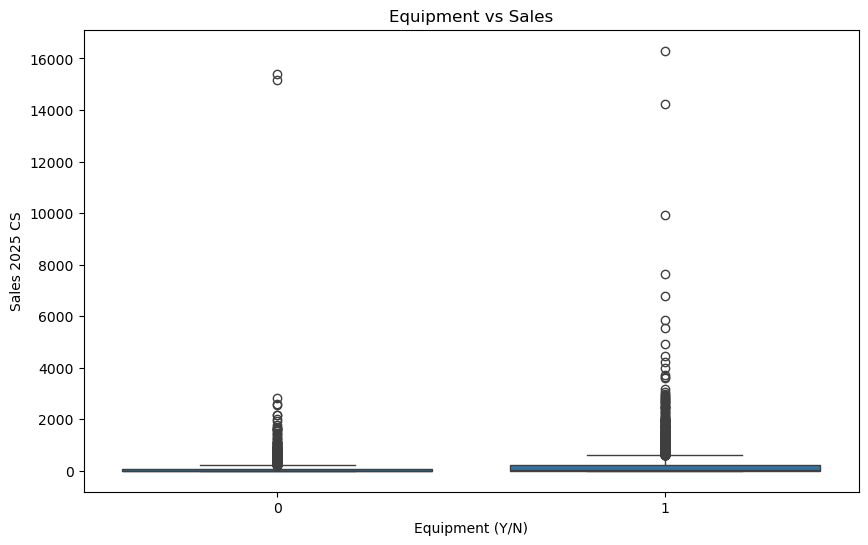

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["Equipment (Y/N)"],
    y=df["Sales 2025 CS"]
)

plt.title("Equipment vs Sales")

plt.show()

### Correlation Analysis

To better understand the relationships between the key variables, a correlation matrix is computed.

This helps identify which factors are most strongly related to sales performance.

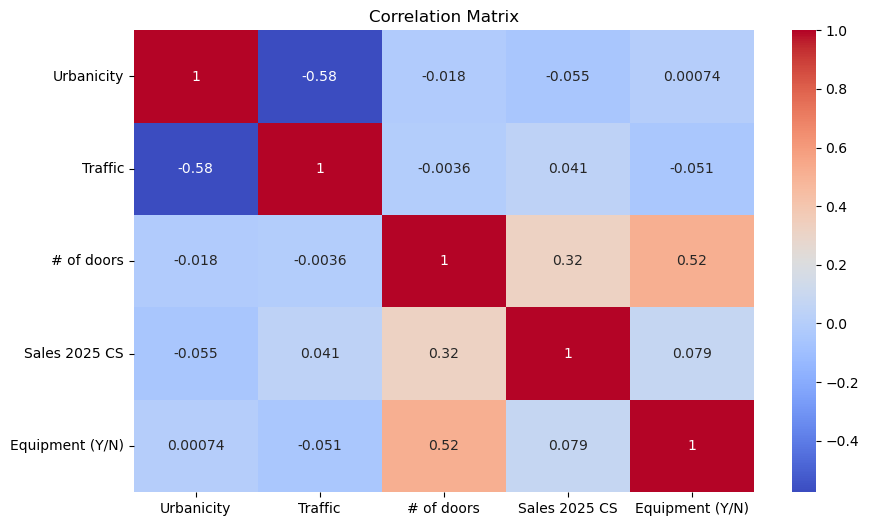

In [9]:
plt.figure(figsize=(10,6))

corr = df[[
    "Urbanicity",
    "Traffic",
    "# of doors",
    "Sales 2025 CS",
    "Equipment (Y/N)"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Feature Selection

For clustering analysis we select variables that influence sales potential:

Urbanicity – level of urbanization  
Traffic – potential customer flow  
Equipment – presence of refrigeration equipment  
Number of refrigerator doors – refrigeration capacity  
Sales – historical sales performance

### Select Features

In [10]:
features = [
    "Urbanicity",
    "Traffic",
    "# of doors",
    "Sales 2025 CS",
    "Equipment (Y/N)"
]

X = df[features]

## Data Scaling

Clustering algorithms rely on distance calculations. Therefore, the data must be standardized so that each variable contributes equally
to the clustering process.

### Scaling Code

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Sales Potential Score

To better evaluate the sales potential of each customer, a composite score is created.

The score combines three important factors:

Traffic – customer flow near the outlet  
Refrigeration capacity – number of refrigerator doors  
Sales performance – historical sales  

This score helps identify customers with higher business potential.

In [12]:
df["Potential Score"] = (
    df["Traffic"] * 0.4 +
    df["# of doors"] * 0.3 +
    df["Sales 2025 CS"] * 0.3
)

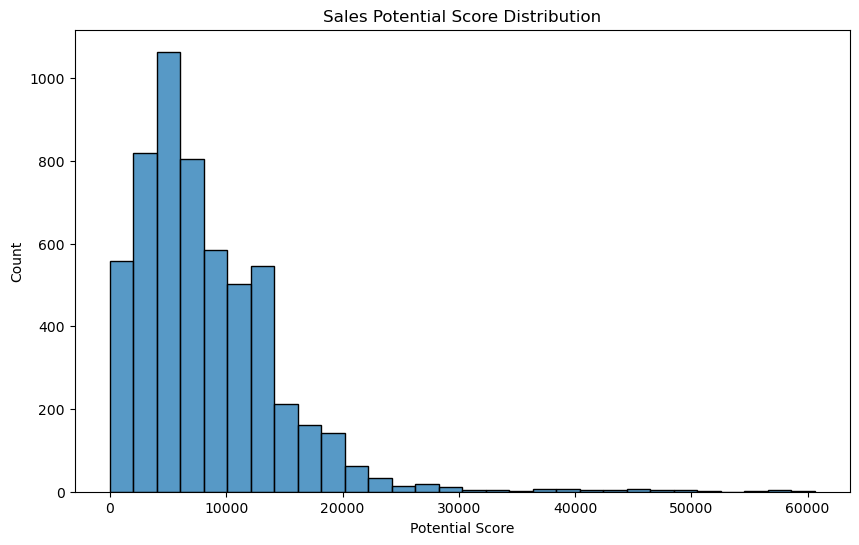

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(df["Potential Score"], bins=30)

plt.title("Sales Potential Score Distribution")

plt.show()

## Determining the Optimal Number of Clusters

### Elbow Method Code

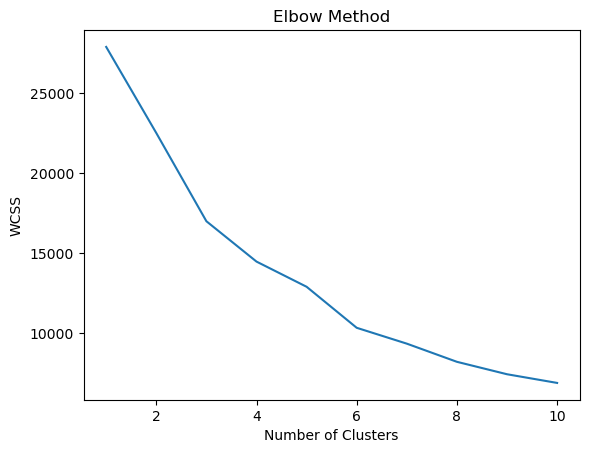

In [14]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

### Hierarchical Clustering

In addition to K-Means clustering, hierarchical clustering is applied to visualize how customers are grouped based on similarity.

A dendrogram is used to show the hierarchical structure of the clusters.

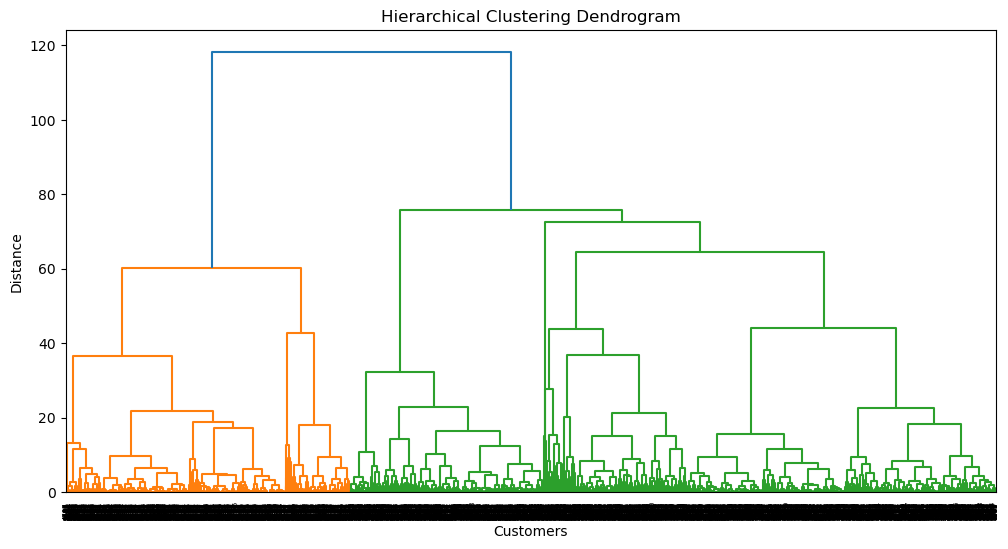

In [15]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Distance")

plt.show()

### K-Means Clustering

In [16]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [ ]:
### Convert Clusters to Business Segments

In [17]:
cluster_means = df.groupby("Cluster")["Sales 2025 CS"].mean().sort_values()

segment_map = {
    cluster_means.index[0]:"Iron",
    cluster_means.index[1]:"Bronze",
    cluster_means.index[2]:"Silver",
    cluster_means.index[3]:"Gold"
}

df["Segment_Level"] = df["Cluster"].map(segment_map)

### Cluster Visualization

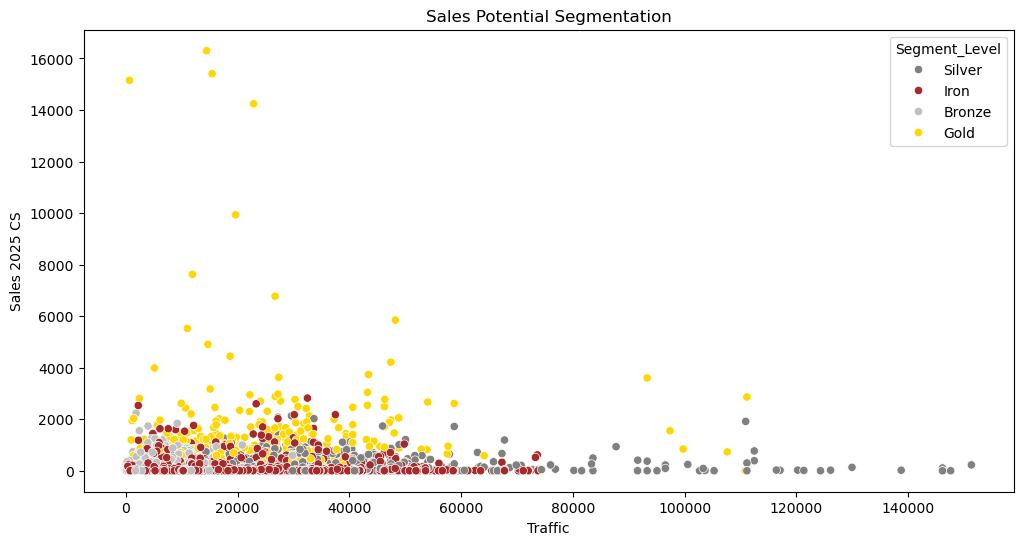

In [14]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x=df["Traffic"],
    y=df["Sales 2025 CS"],
    hue=df["Segment_Level"],
    palette=["gray","brown","silver","gold"]
)

plt.title("Sales Potential Segmentation")

plt.show()

### Cluster Statistics

In [18]:
df.groupby("Segment_Level")[features].mean()

,Urbanicity,Traffic,# of doors,Sales 2025 CS,Equipment (Y/N)
Segment_Level,,,,,
Bronze,5.439037,10340.111946,2.043648,129.074904,1.000000
Gold,3.380054,23900.180836,7.081671,1204.597232,0.994609
Iron,4.079375,20968.688856,0.000000,103.690811,0.000000
Silver,2.497481,31529.305535,1.972292,134.238724,0.991184


## Conclusion

This project analyzed the sales potential of seasonal customers such as stores, bars, and restaurants.

By combining information about traffic levels, refrigeration equipment, refrigerator capacity, and historical sales performance, customers were segmented into four business categories:

Gold – highest sales potential  
Silver – strong potential  
Bronze – moderate potential  
Iron – low potential

These insights can help companies optimize equipment allocation, prioritize customers with higher potential, and improve sales strategies during the summer season.